# Real Estate — Preprocessing and Feature Engineering

Everything `U1_RealEstate-1_EDA` found, acted on. Outliers are filtered, missing values imputed by
neighborhood, new features engineered from combinations of old ones, ordered qualities encoded as
integers, and the remaining categoricals dummy-encoded. The result is written to one CSV that
notebooks 3 through 6 all load.

The engineered features are the interesting part. Summing the floor and basement areas into a
single `Indoor Area`, and turning finished/unfinished basement areas into a *fraction*, replaces
several correlated columns with fewer, more meaningful ones — feature engineering as a remedy for
the collinearity that `U1-4_FeatSelect-1_VIF` measures.

## Learning objectives

- Filter outliers by interquartile range across a set of numeric columns
- Impute missing values with a **group** median rather than a global one
- Engineer aggregate and ratio features from related raw columns
- Ordinal-encode ordered quality ratings with `OrdinalEncoder`
- Dummy-encode the remaining categoricals and write a modeling-ready CSV

## Background

This notebook assumes the findings of `U1_RealEstate-1_EDA` — the missingness pattern, the miscoded
levels, the skew of the target — and the encoder choices from `U1-2_Preprocess`.

As in the diabetes spine, **no scaling happens here**: a scaler must be fit on the training split,
which does not exist yet, so scaling is deferred to each modeling notebook.

**Prerequisites:** `U1_RealEstate-1_EDA` (what the data needs), `U1-2_Preprocess` (encoders)

**Dataset:** `Real Estate Data.csv` in, `Real Estate Data_preprocessed.csv` out.

**References:** https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from tqdm import tqdm

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)
pd.set_option("display.precision", 4)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Read and clean data

In [2]:
data_folder = 'C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/'

df = pd.read_csv(data_folder + 'Real Estate/Real Estate Data.csv', index_col=0, header=0)
df = df.reset_index(drop=True)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1404 entries, 0 to 1403
Data columns (total 68 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Type                      1404 non-null   object 
 1   Zoning Class              1404 non-null   object 
 2   Lot Frontage              1151 non-null   float64
 3   Lot Area                  1404 non-null   int64  
 4   Alley                     84 non-null     object 
 5   Lot Shape                 1404 non-null   object 
 6   Land Contour              1404 non-null   object 
 7   Lot Config                1404 non-null   object 
 8   Land Slope                1404 non-null   object 
 9   Nbhd                      1404 non-null   object 
 10  Location Condition        1404 non-null   object 
 11  Bldg Type                 1404 non-null   object 
 12  House Style               1404 non-null   object 
 13  OvQual                    1404 non-null   int64  
 14  Overall 

,Type,Zoning Class,Lot Frontage,Lot Area,Alley,Lot Shape,Land Contour,Lot Config,Land Slope,Nbhd,Location Condition,Bldg Type,House Style,OvQual,Overall Cond,Built,Year Remod Add,Roof Style,Roof Material,Exterior Primary,Masonry/Veneer,Masonry/Veneer Area,Exterior Qual,Exterior Cond,Foundation,Basement Height,Basement Cond,Basement Exposure,Basement Finish,Basement Finished Area,Basement Unfinished Area,Basement Area,Heating Qual,CentralAir,Electrical,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Kitchen Qual,Total Rooms Above Grade,Functionality,Fireplaces,Fireplce Qual,Garage Type,Garage Yr Built,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Pool Qual,Fence,Sale Type,Sale Condition,Sale Price
0,2-STORY 1946 & NEWER,Resid Low Density,65.0,8450,NaN,Regular,Level,Inside lot,Gentle,College Creek,Normal,1-family Detached,2 story,7,5,2003,2003,Gable,Composite Shingle,Vinyl Siding,Brick Face,196.0,Good,Average,Poured Contrete,"Good (90-99"")",Average,No Exposure,Good Living Quarters,706,150,856,Excellent,Y,Standard Circuit Breakers & Romex,856,854,1710,1,0,2,1,3,1,Good,8,Typical Functionality,0,No Fireplace,Attached to home,2003.0,Rough Finished,2,548,Average,Average,Paved,0,61,0,0,0,0,No Pool,No Fence,Warranty Deed - Conventional,Normal Sale,208500
1,1-STORY 1946 & NEWER,Resid Low Density,80.0,9600,NaN,Regular,Level,Frontage on 2 sides,Gentle,Veenker,Adjacent Feeder St,1-family Detached,1 story,6,8,1976,1976,Gable,Composite Shingle,Metal Siding,NaN,0.0,Average,Average,Cinder Block,"Good (90-99"")",Average,Good Exposure,Avg Living Quarters,978,284,1262,Excellent,Y,Standard Circuit Breakers & Romex,1262,0,1262,0,1,2,0,3,1,Average,6,Typical Functionality,1,Average,Attached to home,1976.0,Rough Finished,2,460,Average,Average,Paved,298,0,0,0,0,0,No Pool,No Fence,Warranty Deed - Conventional,Normal Sale,181500
2,2-STORY 1946 & NEWER,Resid Low Density,68.0,11250,NaN,Slightly irregular,Level,Inside lot,Gentle,College Creek,Normal,1-family Detached,2 story,7,5,2001,2002,Gable,Composite Shingle,Vinyl Siding,Brick Face,162.0,Good,Average,Poured Contrete,"Good (90-99"")",Average,Min Exposure,Good Living Quarters,486,434,920,Excellent,Y,Standard Circuit Breakers & Romex,920,866,1786,1,0,2,1,3,1,Good,6,Typical Functionality,1,Average,Attached to home,2001.0,Rough Finished,2,608,Average,Average,Paved,0,42,0,0,0,0,No Pool,No Fence,Warranty Deed - Conventional,Normal Sale,223500
3,2-STORY 1945 & OLDER,Resid Low Density,60.0,9550,NaN,Slightly irregular,Level,Corner lot,Gentle,Crawford,Normal,1-family Detached,2 story,7,5,1915,1970,Gable,Composite Shingle,Wood Siding,NaN,0.0,Average,Average,Brick & Tile,"Typical (80-89"")",Good,No Exposure,Avg Living Quarters,216,540,756,Good,Y,Standard Circuit Breakers & Romex,961,756,1717,1,0,1,0,3,1,Good,7,Typical Functionality,1,Good,Detached from home,1998.0,Unfinished,3,642,Average,Average,Paved,0,35,272,0,0,0,No Pool,No Fence,Warranty Deed - Conventional,"Abnormal Sale - trade, foreclosure, short sale",140000
4,2-STORY 1946 & NEWER,Resid Low Density,84.0,14260,NaN,Slightly irregular,Level,Frontage on 2 sides,Gentle,Northridge,Normal,1-family Detached,2 story,8,5,2000,2000,Gable,Composite Shingle,Vinyl Siding,Brick Face,350.0,Good,Average,Poured Contrete,"Good (90-99"")",Average,Avg Exposure,Good Living Quarters,655,490,1145,Excellent,Y,Standard Circuit Breakers & Romex,1145,1053,2198,1,0,2,1,4,1,Good,9,Typical Functionality,1,Average,Attached to home,2000.0,Rough Finished,3,836,Average,Average,Paved,192,84,0,0,0,0,No Pool,No Fence,Warranty Deed - Conventional,Normal Sale,250000


In [3]:
df = df.rename(columns = {'OvQual':'Overall Qual',
                          'Built':'Year',
                          'Garage Yr Built':'Year Garage'})

df = df.drop(columns=['Alley'])
df = df.drop(columns=['Masonry/Veneer'])

## 2. Filter Outliers

The filter uses the **interquartile range** rule: for each column, compute
$Q_1$ and $Q_3$, take $\text{IQR} = Q_3 - Q_1$, and drop rows falling outside

$$[\,Q_1 - 1.5\,\text{IQR},\ \ Q_3 + 1.5\,\text{IQR}\,]$$

Quartiles are used rather than the mean and standard deviation because the mean is itself dragged
by the outliers you are trying to find — a rule built on it moves its own goalposts.

Only the **area** columns are filtered. Those are the heavily right-skewed fields identified in
`U1_RealEstate-1_EDA`, where a handful of very large properties would otherwise dominate a
squared-error fit. Applying an IQR filter to every numeric column indiscriminately would discard
legitimate rows on fields where the tail is real information rather than noise.

Note that this drops **rows**, so it shrinks the dataset — a cost worth being conscious of, and one
reason the filter list is short and deliberate.


In [4]:
# filter outliers from a list of float columns via IQR
def filter_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

print(df.shape)
df = filter_outliers(df, ['Sale Price', 'Year', 'Lot Area'])
print(df.shape)

(1404, 66)
(1256, 66)


## 3. Fill nulls

Three columns are imputed, and each is filled with its **neighborhood** median rather than a global
one:

$$\hat{x}_i = \text{median}\{\,x_j : \text{Nbhd}_j = \text{Nbhd}_i\,\}$$

The reasoning is that these fields genuinely vary by location. Lot frontage in a dense older
neighborhood is systematically different from a newer subdivision, so a single global median would
push every missing value toward a compromise that fits nowhere. The `groupby` medians computed just
above are what make the grouped fill possible.

`Year Garage` deserves a note: a missing value there usually means **no garage**, not an unrecorded
date — a case where the "missing" is itself information. Filling it with a neighborhood median
imputes a plausible year for a garage that does not exist, which is a modelling compromise worth
knowing about rather than a silent fix.


In [5]:
gb1 = df.groupby(["Nbhd"])['Lot Frontage'].median().sort_values()

def fill_1(r):
    n = r.Nbhd
    
    x = r['Lot Frontage']
    
    if pd.isna(x):
        return gb1[n]
    else:
        return x
    # end
# end

df['Lot Frontage'] = df.apply(fill_1, axis=1)

In [6]:
gb2 = df.groupby(["Nbhd"])['Year Garage'].median().sort_values()

def fill_2(r):
    n = r.Nbhd
    
    x = r['Year Garage']
    
    if pd.isna(x):
        return gb2[n]
    else:
        return x
    # end
# end

df['Year Garage'] = df.apply(fill_2, axis=1)

In [7]:
gb3 = df.groupby(["Nbhd"])['Masonry/Veneer Area'].median().sort_values()

def fill_3(r):
    n = r.Nbhd
    
    x = r['Masonry/Veneer Area']
    
    if pd.isna(x):
        return gb2[n]
    else:
        return x
    # end
# end

df['Masonry/Veneer Area'] = df.apply(fill_3, axis=1)

## 4. Feature engineering

### 4.1 Central Air

In [8]:
df['CentralAir'] = df['CentralAir'].replace(
    {
        'Y':1,
        'N':0
    }
)

df = df.rename(
    columns={
        'CentralAir':'Central Air'
    }
)

### 4.2 Floors

In [9]:
def get_floors(x):
    if x > 0:
        return 2
    else:
        return 1
    # end
# end

df['Floors'] = df['2nd Floor Area'].apply(get_floors)

### 4.3 Areas

The raw file carries a separate area column for every part of the house, and they are strongly
correlated with each other — bigger houses are bigger everywhere. That is precisely the
multicollinearity `U1-4_FeatSelect-1_VIF` measures, and the cleanest remedy is not to drop columns
after the fact but to **combine them up front** into totals that mean something:

- `Indoor Area` = 1st floor + 2nd floor + basement
- `Outdoor Area` = porches + deck + garage

One column that means "how much house is there" is easier for a model to use, and easier for a
person to interpret, than five correlated pieces. The component columns are dropped afterwards to
avoid keeping both the parts and the whole — which would be an exact linear dependency, the
infinite-VIF case.


In [10]:
df.columns[df.columns.str.contains("Area")].sort_values()

Index(['1st Floor Area', '2nd Floor Area', '3 Season Porch Area',
       'Basement Area', 'Basement Finished Area', 'Basement Unfinished Area',
       'Enclosed Porch Area', 'Garage Area', 'Living Area Above Grade',
       'Lot Area', 'Masonry/Veneer Area', 'Open Porch Area', 'Pool Area',
       'Screen Porch Area', 'Wood Deck Area'],
      dtype='object')

<Axes: >

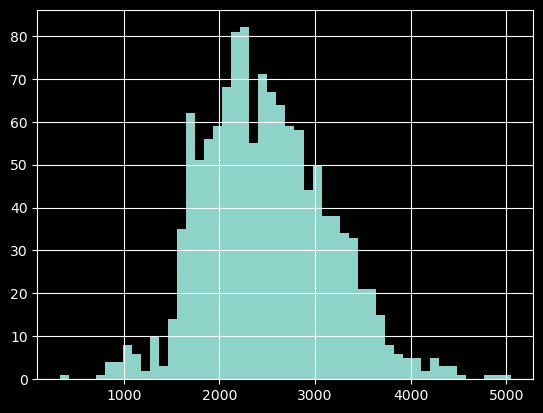

In [11]:
df['Indoor Area'] = df[
    [
        '1st Floor Area', '2nd Floor Area', 'Basement Area'
    ]
].sum(axis=1)

df['Indoor Area'].hist(bins=50)

<Axes: >

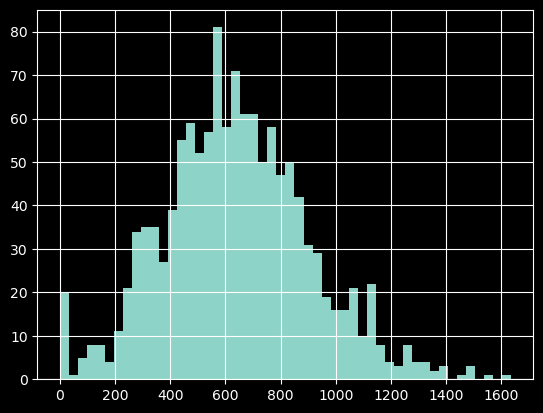

In [12]:
df['Outdoor Area'] = df[
    [
        '3 Season Porch Area', 'Enclosed Porch Area', 'Garage Area',
        'Open Porch Area', 'Pool Area', 'Screen Porch Area', 'Wood Deck Area'
    ]
].sum(axis=1)

df['Outdoor Area'].hist(bins=50)

### 4.4 Basement finished area fraction

A **ratio** rather than a sum, and for a different reason. Finished and unfinished basement areas
are two numbers whose sum is already captured in `Indoor Area`; what they carry beyond that is the
*proportion* of the basement that is usable living space:

$$\text{finished fraction} = \frac{\text{finished}}{\text{finished} + \text{unfinished}}$$

That quantity is scale-free — it says something about quality rather than size — and so is not
redundant with the total. This is the general pattern for good feature engineering: sums capture
magnitude, ratios capture character, and the two are worth keeping separately.


In [13]:
df['Basement Finished Area Fraction'] = df['Basement Finished Area'] / df[['Basement Finished Area', 'Basement Unfinished Area']].sum(axis=1)
df['Basement Finished Area Fraction'] = df['Basement Finished Area Fraction'].fillna(0)
df['Basement Finished Area Fraction']

0       0.8248
1       0.7750
2       0.5283
3       0.2857
4       0.5721
         ...  
1399    0.0000
1400    0.5729
1401    0.2387
1402    1.0000
1403    0.8592
Name: Basement Finished Area Fraction, Length: 1256, dtype: float64

In [14]:
df = df.drop(
    columns=[
       '1st Floor Area', '2nd Floor Area', '3 Season Porch Area',
       'Basement Area', 'Basement Finished Area', 'Basement Unfinished Area',
       'Enclosed Porch Area', 'Garage Area', 'Living Area Above Grade',
       'Open Porch Area', 'Pool Area', 'Screen Porch Area', 'Wood Deck Area'
    ]
)

### 4.5 Label encode qualities

These columns rate things Poor / Fair / Average / Good / Excellent — a genuine ordering, so
`OrdinalEncoder` with an explicit `categories` list maps them to 0…4 and preserves it in one column.
Passing the order explicitly matters: left to itself the encoder would sort alphabetically, giving
Excellent < Fair < Good < Poor, which is nonsense.

`Basement Height` needs the extra `.split(" ")[0]` step because its values carry units alongside the
rating, and `Pool Qual` collapses unseen levels to `"Poor"` — most houses have no pool, and the
encoder needs every value to appear in its known category list.


In [15]:
df.columns[df.columns.str.contains("Qual")].sort_values()

Index(['Exterior Qual', 'Fireplce Qual', 'Garage Qual', 'Heating Qual',
       'Kitchen Qual', 'Overall Qual', 'Pool Qual'],
      dtype='object')

In [16]:
df.columns[df.columns.str.contains("Cond")].sort_values()

Index(['Basement Cond', 'Exterior Cond', 'Garage Cond', 'Location Condition',
       'Overall Cond', 'Sale Condition'],
      dtype='object')

In [17]:
from sklearn.preprocessing import OrdinalEncoder

# Define known categories
quality_order = ["Poor", "Fair", "Average", "Good", "Excellent"]

# Identify categorical columns that contain 'Average'
cols = df.columns[df.isin(['Average']).any(axis=0)]

# Replace unknown values with "Poor"
df[cols] = df[cols].applymap(lambda x: x if x in quality_order else "Poor")

# Initialize and fit OrdinalEncoder on a single-column DataFrame
encoder = OrdinalEncoder(
    categories=[quality_order]
)

encoder.fit(
    np.array(quality_order)[:,np.newaxis]
)

# Transform each column separately in a loop
for c in cols:
    df[c] = encoder.transform(df[[c]]).astype(int)[:,0]
# end

df[cols].head()

,Exterior Qual,Exterior Cond,Basement Cond,Heating Qual,Kitchen Qual,Fireplce Qual,Garage Qual,Garage Cond
0,3,2,2,4,3,0,2,2
1,2,2,2,4,2,2,2,2
2,3,2,2,4,3,2,2,2
3,2,2,3,3,3,3,2,2
4,3,2,2,4,3,2,2,2


In [18]:
df['Basement Height'] = df['Basement Height'].apply(
    lambda x: x.split(" ")[0]
)

df['Basement Height'] = df['Basement Height'].apply(
    lambda x: x if x != "Typical" else "Average"
)

df['Basement Height'] = df['Basement Height'].apply(
    lambda x: x if x in quality_order else "Poor"
)

df['Basement Height'] = encoder.transform(df[['Basement Height']]).astype(int)[:,0]
df['Basement Height'].head()

0    3
1    3
2    3
3    2
4    3
Name: Basement Height, dtype: int64

In [19]:
df['Pool Qual'] = df['Pool Qual'].apply(
    lambda x: x if x in quality_order else "Poor"
)

df['Pool Qual'] = encoder.transform(df[['Pool Qual']]).astype(int)[:,0]
df['Pool Qual'].head()

0    0
1    0
2    0
3    0
4    0
Name: Pool Qual, dtype: int64

### 4.6 Get dummies for remaining string columns

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1256 entries, 0 to 1403
Data columns (total 57 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Type                             1256 non-null   object 
 1   Zoning Class                     1256 non-null   object 
 2   Lot Frontage                     1256 non-null   float64
 3   Lot Area                         1256 non-null   int64  
 4   Lot Shape                        1256 non-null   object 
 5   Land Contour                     1256 non-null   object 
 6   Lot Config                       1256 non-null   object 
 7   Land Slope                       1256 non-null   object 
 8   Nbhd                             1256 non-null   object 
 9   Location Condition               1256 non-null   object 
 10  Bldg Type                        1256 non-null   object 
 11  House Style                      1256 non-null   object 
 12  Overall Qual             

In [21]:
# new dummy dataframe to merge
df_dum = pd.DataFrame()

# loop through object columns
obj_cols = df.select_dtypes(include=object)

for c in obj_cols:
    # get dummies per column
    dummy = pd.get_dummies(df[c], prefix=c, dtype=int)

    # remove most frequent dummies to reduce multi-collinearity
    dummy_sum = dummy.sum(axis=0)
    col_to_drop = dummy_sum.idxmax()
    dummy = dummy.drop(columns=[col_to_drop])

    # append dummies so far
    df_dum = pd.concat([df_dum, dummy], axis=1)
# end

df_dum

,Type_1 STORY PUD,Type_1-1/2 STORY ALL AGES,Type_1-STORY 1945 & OLDER,Type_1-STORY PUD,Type_2 FAMILY CONVERSION,Type_2-1/2 STORY ALL AGES,Type_2-STORY 1945 & OLDER,Type_2-STORY 1946 & NEWER,Type_2-STORY PUD,Type_DUPLEX,Type_SPLIT FOYER,Type_SPLIT OR MULTI-LEVEL,Zoning Class_Commercial,Zoning Class_Floating Village Resid,Zoning Class_Resid High Density,Zoning Class_Resid Med Density,Lot Shape_Irregular,Lot Shape_Slightly irregular,Land Contour_Banked,Land Contour_Depression,Land Contour_Hillside,Lot Config_Corner lot,Lot Config_Cul-de-sac,Lot Config_Frontage on 2 sides,Lot Config_Frontage on 3 sides,Land Slope_Moderate,Land Slope_Severe,Nbhd_Bloomington Heights,Nbhd_Bloomington Hts,Nbhd_Bluestem,Nbhd_Briardale,Nbhd_Brookside,Nbhd_Clear Creek,Nbhd_College Creek,Nbhd_Crawford,Nbhd_Edwards,Nbhd_Gilbert,Nbhd_Iowa DOT and Rail Road,Nbhd_Meadow Village,Nbhd_Mitchell,Nbhd_Northpark Villa,Nbhd_Northridge,Nbhd_Northridge Heights,Nbhd_Northwest Ames,Nbhd_Old Town,Nbhd_Sawyer,Nbhd_Sawyer West,Nbhd_Somerset,Nbhd_South & West of Iowa State,Nbhd_Stone Brook,...,Exterior Primary_Stucco,Exterior Primary_Wood Shingles,Exterior Primary_Wood Siding,Foundation_Brick & Tile,Foundation_Cinder Block,Foundation_Slab,Foundation_Stone,Foundation_Wood,Basement Exposure_Avg Exposure,Basement Exposure_Good Exposure,Basement Exposure_Min Exposure,Basement Exposure_No Basement,Basement Finish_Avg Living Quarters,Basement Finish_Avg Rec Room,Basement Finish_Below Avg Living Quarters,Basement Finish_Good Living Quarters,Basement Finish_Low Quality,Basement Finish_No Basement,Electrical_60 AMP Fuse Box and mostly Romex wiring (Fair),Electrical_Fuse Box over 60 AMP and all Romex wiring (Average),Functionality_Major Deductions 1,Functionality_Minor Deductions 1,Functionality_Minor Deductions 2,Functionality_Moderate Deductions,Garage Type_Basement Garage,Garage Type_Built-In (Garage with Room),Garage Type_Car Port,Garage Type_Detached from home,Garage Type_More than one type of garage,Garage Type_No Garage,Garage Finish_Finished,Garage Finish_No Garage,Garage Finish_Rough Finished,Paved Drive_Dirt/Gravel,Paved Drive_Partial Pavement,Fence_Good Privacy,Fence_Good Wood,Fence_Minimum Privacy,Fence_Minimum Wood/Wire,Sale Type_Contract 15% Down payment regular terms,Sale Type_Contract Low Down,Sale Type_Contract Low Down payment and low interest,Sale Type_Contract Low Interest,Sale Type_Court Officer Deed/Estate,Sale Type_Home just constructed and sold,Sale Type_Warranty Deed - Cash,"Sale Condition_Abnormal Sale - trade, foreclosure, short sale","Sale Condition_Allocation - two linked properties with separate deeds, typically condo with a garage unit",Sale Condition_Home was not completed when last assessed (associated with New Homes),Sale Condition_Sale between family members
0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [22]:
df = pd.concat([df, df_dum], axis=1)

In [23]:
df

,Type,Zoning Class,Lot Frontage,Lot Area,Lot Shape,Land Contour,Lot Config,Land Slope,Nbhd,Location Condition,Bldg Type,House Style,Overall Qual,Overall Cond,Year,Year Remod Add,Roof Style,Roof Material,Exterior Primary,Masonry/Veneer Area,Exterior Qual,Exterior Cond,Foundation,Basement Height,Basement Cond,Basement Exposure,Basement Finish,Heating Qual,Central Air,Electrical,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Kitchen Qual,Total Rooms Above Grade,Functionality,Fireplaces,Fireplce Qual,Garage Type,Year Garage,Garage Finish,Garage Cars,Garage Qual,Garage Cond,Paved Drive,Pool Qual,Fence,...,Exterior Primary_Stucco,Exterior Primary_Wood Shingles,Exterior Primary_Wood Siding,Foundation_Brick & Tile,Foundation_Cinder Block,Foundation_Slab,Foundation_Stone,Foundation_Wood,Basement Exposure_Avg Exposure,Basement Exposure_Good Exposure,Basement Exposure_Min Exposure,Basement Exposure_No Basement,Basement Finish_Avg Living Quarters,Basement Finish_Avg Rec Room,Basement Finish_Below Avg Living Quarters,Basement Finish_Good Living Quarters,Basement Finish_Low Quality,Basement Finish_No Basement,Electrical_60 AMP Fuse Box and mostly Romex wiring (Fair),Electrical_Fuse Box over 60 AMP and all Romex wiring (Average),Functionality_Major Deductions 1,Functionality_Minor Deductions 1,Functionality_Minor Deductions 2,Functionality_Moderate Deductions,Garage Type_Basement Garage,Garage Type_Built-In (Garage with Room),Garage Type_Car Port,Garage Type_Detached from home,Garage Type_More than one type of garage,Garage Type_No Garage,Garage Finish_Finished,Garage Finish_No Garage,Garage Finish_Rough Finished,Paved Drive_Dirt/Gravel,Paved Drive_Partial Pavement,Fence_Good Privacy,Fence_Good Wood,Fence_Minimum Privacy,Fence_Minimum Wood/Wire,Sale Type_Contract 15% Down payment regular terms,Sale Type_Contract Low Down,Sale Type_Contract Low Down payment and low interest,Sale Type_Contract Low Interest,Sale Type_Court Officer Deed/Estate,Sale Type_Home just constructed and sold,Sale Type_Warranty Deed - Cash,"Sale Condition_Abnormal Sale - trade, foreclosure, short sale","Sale Condition_Allocation - two linked properties with separate deeds, typically condo with a garage unit",Sale Condition_Home was not completed when last assessed (associated with New Homes),Sale Condition_Sale between family members
0,2-STORY 1946 & NEWER,Resid Low Density,65.0,8450,Regular,Level,Inside lot,Gentle,College Creek,Normal,1-family Detached,2 story,7,5,2003,2003,Gable,Composite Shingle,Vinyl Siding,196.0,3,2,Poured Contrete,3,2,No Exposure,Good Living Quarters,4,1,Standard Circuit Breakers & Romex,1,0,2,1,3,1,3,8,Typical Functionality,0,0,Attached to home,2003.0,Rough Finished,2,2,2,Paved,0,No Fence,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1-STORY 1946 & NEWER,Resid Low Density,80.0,9600,Regular,Level,Frontage on 2 sides,Gentle,Veenker,Adjacent Feeder St,1-family Detached,1 story,6,8,1976,1976,Gable,Composite Shingle,Metal Siding,0.0,2,2,Cinder Block,3,2,Good Exposure,Avg Living Quarters,4,1,Standard Circuit Breakers & Romex,0,1,2,0,3,1,2,6,Typical Functionality,1,2,Attached to home,1976.0,Rough Finished,2,2,2,Paved,0,No Fence,...,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2-STORY 1946 & NEWER,Resid Low Density,68.0,11250,Slightly irregular,Level,Inside lot,Gentle,College Creek,Normal,1-family Detached,2 story,7,5,2001,2002,Gable,Composite Shingle,Vinyl Siding,162.0,3,2,Poured Contrete,3,2,Min Exposure,Good Living Quarters,4,1,Standard Circuit Breakers & Romex,1,0,2,1,3,1,3,6,Typical Functionality,1,2,Attached to home,2001.0,Rough Finished,2,2,2,Paved,0,No Fence,...,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2-STORY 1945 & OLDER,Resid Low Density,60.0,9550,Slightly irregular,Level,Corner lot,Gentle,

In [24]:
df.to_csv(data_folder + 'Real Estate/Real Estate Data_preprocessed.csv', index=False)

## Review

- **Group-wise imputation beats a global median** when the grouping is informative: `Lot Frontage`,
  `Year Garage`, and `Masonry/Veneer Area` are all filled by **neighborhood** median.
- **IQR filtering** removes extreme values from the skewed area columns, on the argument from
  `U1_RealEstate-1_EDA` that a handful of outliers dominate a squared-error fit.
- **Feature engineering reduces collinearity.** Several correlated area columns collapse into
  `Indoor Area`, `Outdoor Area`, and a finished-basement *fraction* — fewer columns carrying more
  meaning, and a smaller VIF problem downstream.
- **Ordered qualities are ordinal-encoded**, preserving Poor < Fair < Average < … in one column,
  while unordered categoricals become dummies.
- **No scaling here**, deliberately — it belongs after the train/test split, inside each modeling
  notebook.
- **Re-running this notebook rewrites the CSV** that `U1_RealEstate-3_Regression`, `-4_Keras`,
  `-5_FeatSelect`, and `-6_Interp` all read, so those must be re-run after it.